**Описание данных из датасета: график вывода длин транзакций, список уникальных товаров**

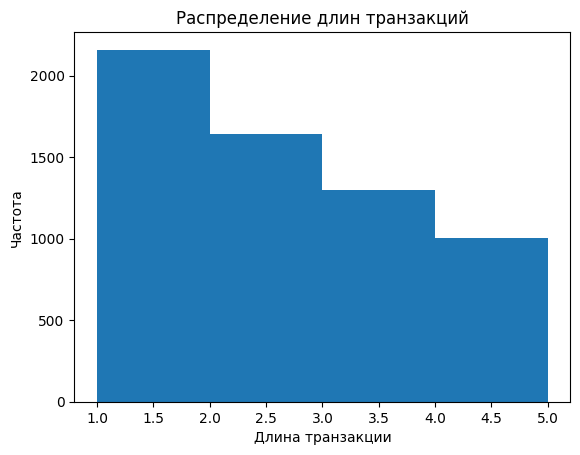

{'mayonnaise', 'cake bar', 'specialty bar', 'flour', 'brandy', 'abrasive cleaner', 'popcorn', 'canned fish', 'frozen potato products', 'bottled water', 'dish cleaner', 'dog food', 'canned fruit', 'pip fruit', 'rubbing alcohol', 'organic products', 'whole milk', 'tea', 'photo/film', 'margarine', 'fish', 'waffles', 'female sanitary products', 'frozen fish', 'sauces', 'butter', 'roll products ', 'chocolate marshmallow', 'liquor', 'sparkling wine', 'pot plants', 'misc. beverages', 'rum', 'ketchup', 'chocolate', 'mustard', 'house keeping products', 'candy', 'dental care', 'light bulbs', 'nuts/prunes', 'whisky', 'hamburger meat', 'oil', 'brown bread', 'beverages', 'long life bakery product', 'decalcifier', 'flower (seeds)', 'chewing gum', 'rice', 'frozen meals', 'cookware', 'artif. sweetener', 'salty snack', 'hard cheese', 'soap', 'canned beer', 'detergent', 'curd', 'dishes', 'meat', 'frozen dessert', 'white bread', 'seasonal products', 'nut snack', 'flower soil/fertilizer', 'male cosmetics'

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
import networkx as nx
import numpy as np

all_data = pd.read_csv('groceries.csv', sep=',', encoding='utf-8', on_bad_lines='skip')

#Анализ транзакций
transaction_lengths = all_data.notnull().sum(axis=1)
plt.hist(transaction_lengths, bins=range(1, max(transaction_lengths) + 2))
plt.xlabel('Длина транзакции')
plt.ylabel('Частота')
plt.title('Распределение длин транзакций')
plt.show()
#Очистка данных
np_data = all_data.to_numpy()
np_data = [[elem for elem in row[1:] if isinstance(elem,str)] for row in np_data]
#Список уникальных товаров
unique_items = set()
for row in np_data:
    for elem in row:
        unique_items.add(elem)
print(unique_items)
te = TransactionEncoder()
te_ary = te.fit(np_data).transform(np_data)
data = pd.DataFrame(te_ary, columns=te.columns_)

**Алгоритм FPG**

Количество частых наборов: 65
    support                    itemsets
0  0.033743                    (yogurt)
1  0.020966                    (coffee)
2  0.010156             (cream cheese )
3  0.054709                (whole milk)
4  0.013432  (long life bakery product)
Количество правил: 7
          antecedents   consequents  antecedent support  consequent support  \
0        (whole milk)  (rolls/buns)            0.054709            0.074693   
1              (soda)  (rolls/buns)            0.079607            0.074693   
2        (rolls/buns)        (soda)            0.074693            0.079607   
3     (bottled water)        (soda)            0.039967            0.079607   
4  (other vegetables)  (whole milk)            0.040786            0.054709   

    support  confidence      lift  representativity  leverage  conviction  \
0  0.005569    0.101796  1.362866               1.0  0.001483    1.030175   
1  0.009828    0.123457  1.652859               1.0  0.003882    1.055632   
2  

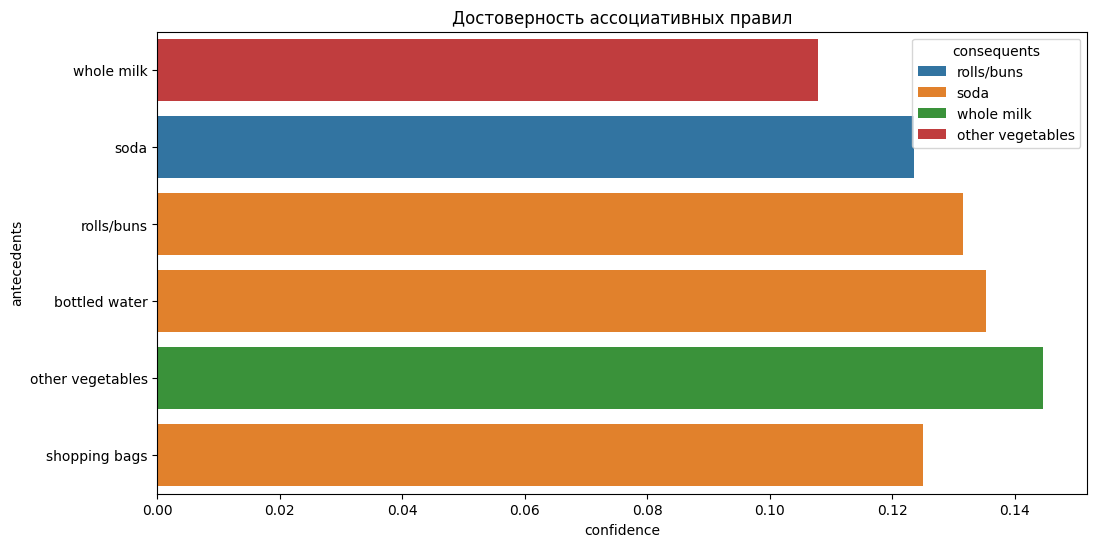

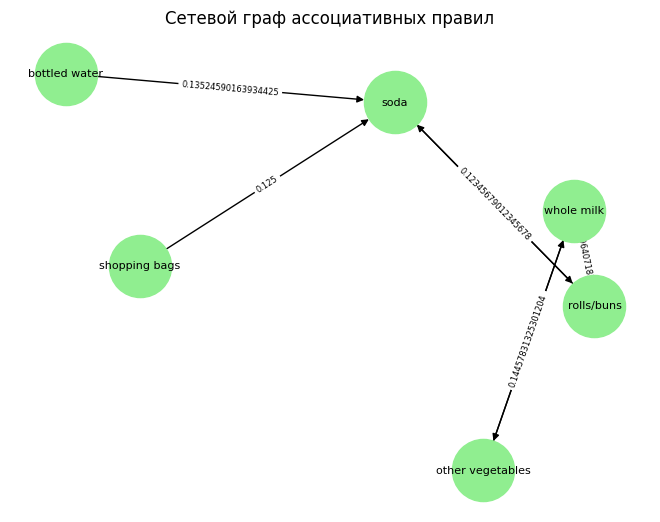

In [ ]:


df1 = fpgrowth(data, min_support=0.005, use_colnames=True)
print(f"Количество частых наборов: {len(df1)}")
print(df1.head())

# Ассоциативные правила
rules = association_rules(df1, metric="confidence", min_threshold=0.1)
print(f"Количество правил: {len(rules)}")
print(rules.head())

# Если правила есть, строим графики
if len(rules) > 0:
    import matplotlib.pyplot as plt
    import seaborn as sns
    import networkx as nx

    # График достоверности
    rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
    plt.figure(figsize=(12, 6))
    sns.barplot(x='confidence', y='antecedents', data=rules, hue='consequents', dodge=False)
    plt.title('Достоверность ассоциативных правил')
    plt.show()

    # Граф
    G = nx.DiGraph()
    for _, row in rules.iterrows():
        G.add_edge(row['antecedents'], row['consequents'], weight=row['confidence'])
    pos = nx.spring_layout(G, k=0.5)
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightgreen', font_size=8, arrows=True)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
    plt.title('Сетевой граф ассоциативных правил')
    plt.show()
else:
    print("Нет правил для визуализации. Попробуйте уменьшить min_support и min_threshold.")



Существующие ассоциативные правила (FPG):

Shopping bag - soda (достоверность 0.125)

Soda - rolls/buns (достоверность 0.123)

Rolls/buns - whole milk (достоверность 0.102)

Whole milk - other vegetables (достоверность 0.1446)

Bottled water - soda (достоверность 0.135)

**Алгоритм Apriori**

Частые наборы:
    support         itemsets
0  0.006880       (UHT-milk)
1  0.006880      (beverages)
2  0.037674   (bottled beer)
3  0.039967  (bottled water)
4  0.023751    (brown bread)

Ассоциативные правила:
          antecedents         consequents  antecedent support  \
0     (bottled water)              (soda)            0.039967   
1  (other vegetables)        (whole milk)            0.040786   
2        (whole milk)  (other vegetables)            0.054709   
3              (soda)        (rolls/buns)            0.079607   
4        (rolls/buns)              (soda)            0.074693   

   consequent support   support  confidence      lift  representativity  \
0            0.079607  0.005405    0.135246  1.698922               1.0   
1            0.054709  0.005897    0.144578  2.642666               1.0   
2            0.040786  0.005897    0.107784  2.642666               1.0   
3            0.074693  0.009828    0.123457  1.652859               1.0   
4            0.079607

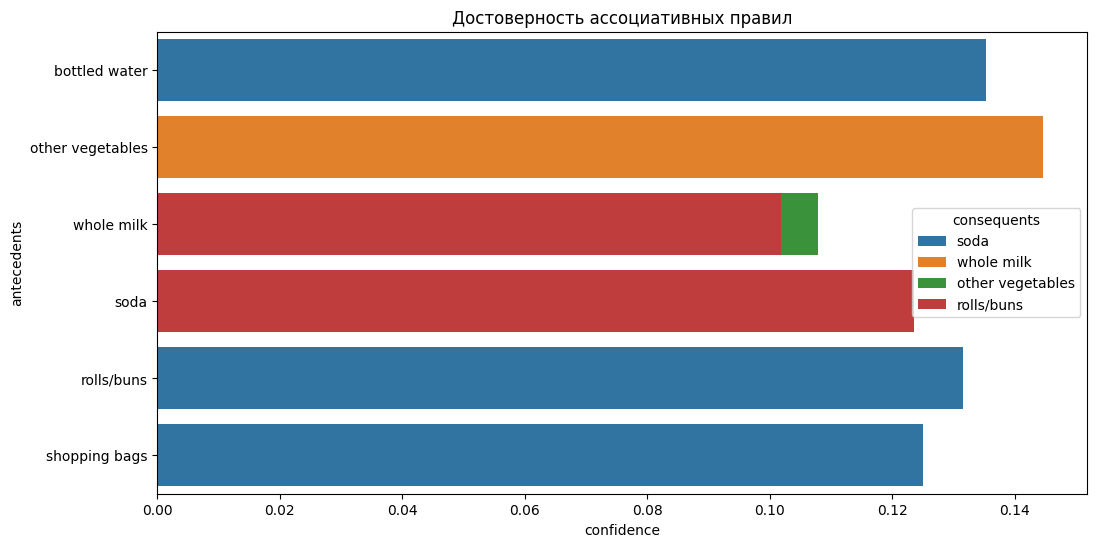

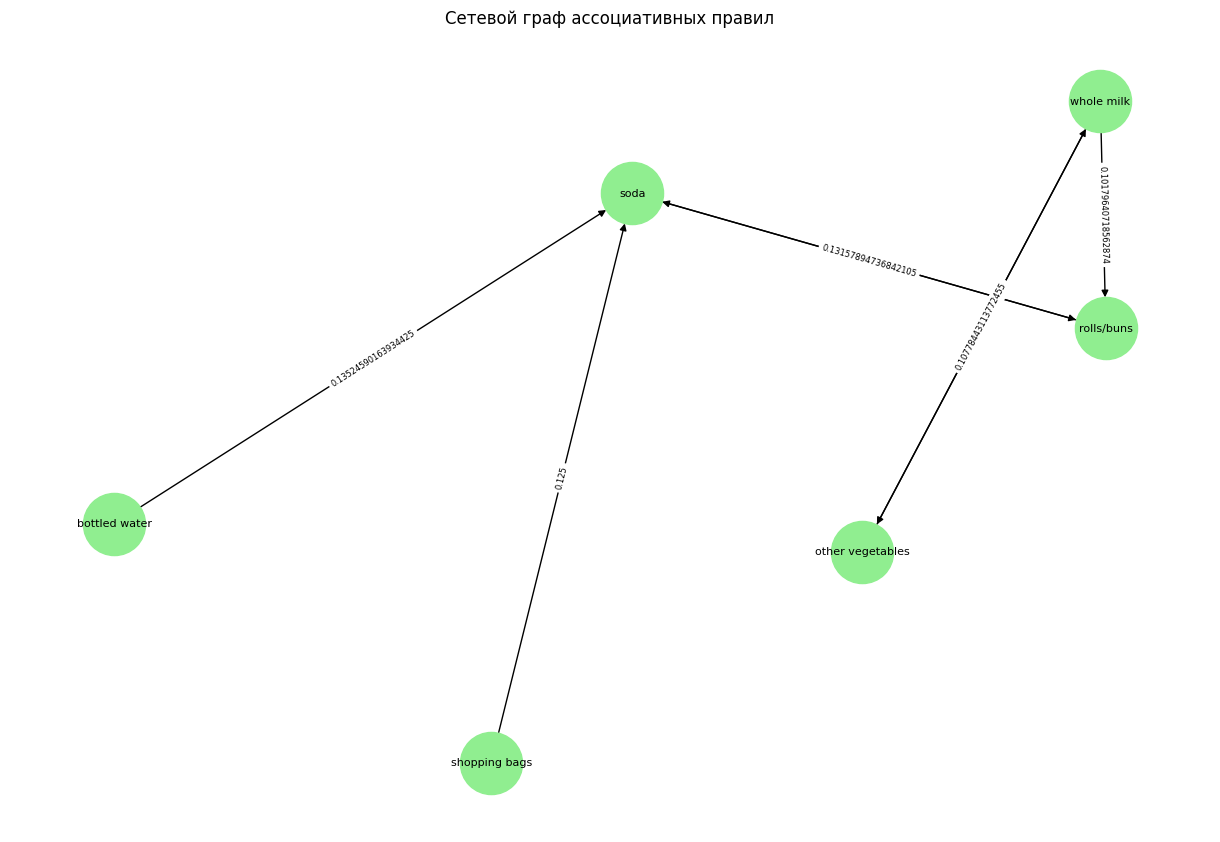

In [3]:

frequent_itemsets = apriori(data, min_support=0.005, use_colnames=True)

# 5. Формирование ассоциативных правил
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

# 6. Вывод результатов
print("Частые наборы:")
print(frequent_itemsets.head())

print("\nАссоциативные правила:")
print(rules.head())

# 7. Визуализация результатов
if not rules.empty:
    # График достоверности правил
    rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

    plt.figure(figsize=(12, 6))
    sns.barplot(x='confidence', y='antecedents', data=rules, hue='consequents', dodge=False)
    plt.title('Достоверность ассоциативных правил')
    plt.show()

    # Визуализация графа ассоциативных правил
    G = nx.DiGraph()
    for _, row in rules.iterrows():
        G.add_edge(row['antecedents'], row['consequents'], weight=row['confidence'])

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.5)
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightgreen', font_size=8, arrows=True)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
    plt.title('Сетевой граф ассоциативных правил')
    plt.show()
else:
    print("Нет правил для визуализации. Попробуйте уменьшить min_support или min_threshold.")

Существующие ассоциативные правила (Apriori):

Shopping bag - soda (достоверность 0.125)

Soda - rolls/buns (достоверность 0.132)

Rolls/buns - whole milk (достоверность 0.102)

Whole milk - other vegetables (достоверность 0.1446)

Bottled water - soda (достоверность 0.135)

     support          itemsets
5   0.079607              soda
6   0.074693        rolls/buns
3   0.054709        whole milk
18  0.040786  other vegetables
37  0.040622     shopping bags
14  0.039967     bottled water
8   0.039312        newspapers
23  0.037674      bottled beer
0   0.033743            yogurt
12  0.031613       canned beer


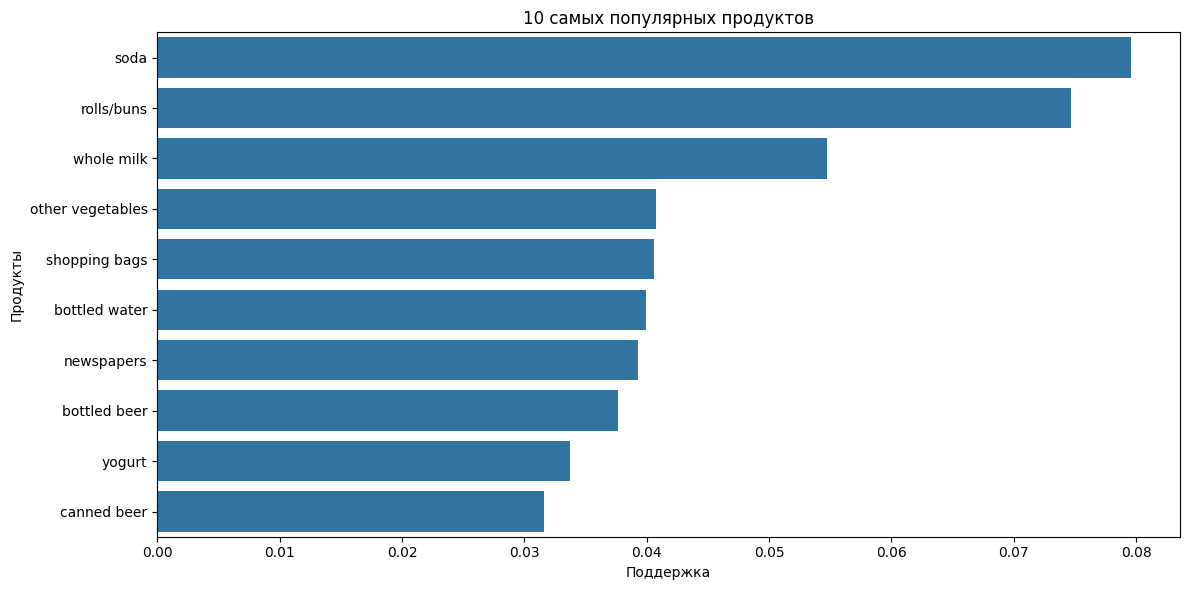

In [4]:

df1['itemsets'] = df1['itemsets'].apply(lambda x: ', '.join(list(x)))
top_products = df1.sort_values(by='support', ascending=False).head(10)
print(top_products)
plt.figure(figsize=(12, 6))
sns.barplot(x='support', y='itemsets', data=top_products)
plt.title('10 самых популярных продуктов')
plt.xlabel('Поддержка')
plt.ylabel('Продукты')
plt.tight_layout()
plt.show()

**Определение минимального значения поддержки для составления правил из 1, 2, и т.д. объектов**

В качестве максимального значения поддержки берется самое большое значение из предыдущего графика (в нашем случае это примерно 0.08)

In [11]:
max_k = 4
min_support_by_k = {}

for k in range(1, max_k + 1):
    found = False
    for sup in np.arange(0.08, 0.00001, -0.0005):
        freq_items = apriori(data, min_support=sup, use_colnames=True)
        freq_k = freq_items[freq_items['itemsets'].apply(lambda x: len(x) == k)]
        if not freq_k.empty:
            min_support_by_k[k] = round(sup, 3)
            print(f"Длина {k}: min_support = {sup:.3f}")
            found = True
            break
    if not found:
        min_support_by_k[k] = None
        print(f"Длина {k}: наборы не найдены даже при min_support=0.0001")

Длина 1: min_support = 0.080
Длина 2: min_support = 0.009
Длина 3: min_support = 0.001
Длина 4: наборы не найдены даже при min_support=0.0001


**Последовательно меняя параметры (значения поддержки и достоверности) одного из алгоритмов получить наборы ассоциативных правил.**

Частые наборы:
    support                 itemsets
0  0.002293  (Instant food products)
1  0.006880               (UHT-milk)
2  0.003276          (baking powder)
3  0.003604                   (beef)
4  0.002785                (berries)

Ассоциативные правила:
        antecedents     consequents  antecedent support  consequent support  \
0        (UHT-milk)    (rolls/buns)            0.006880            0.074693   
1          (liquor)  (bottled beer)            0.008190            0.037674   
2  (red/blush wine)  (bottled beer)            0.011302            0.037674   
3    (bottled beer)          (soda)            0.037674            0.079607   
4   (bottled water)          (soda)            0.039967            0.079607   

    support  confidence      lift  representativity  leverage  conviction  \
0  0.001147    0.166667  2.231360               1.0  0.000633    1.110369   
1  0.002457    0.300000  7.963043               1.0  0.002148    1.374751   
2  0.001638    0.144928  3.846881

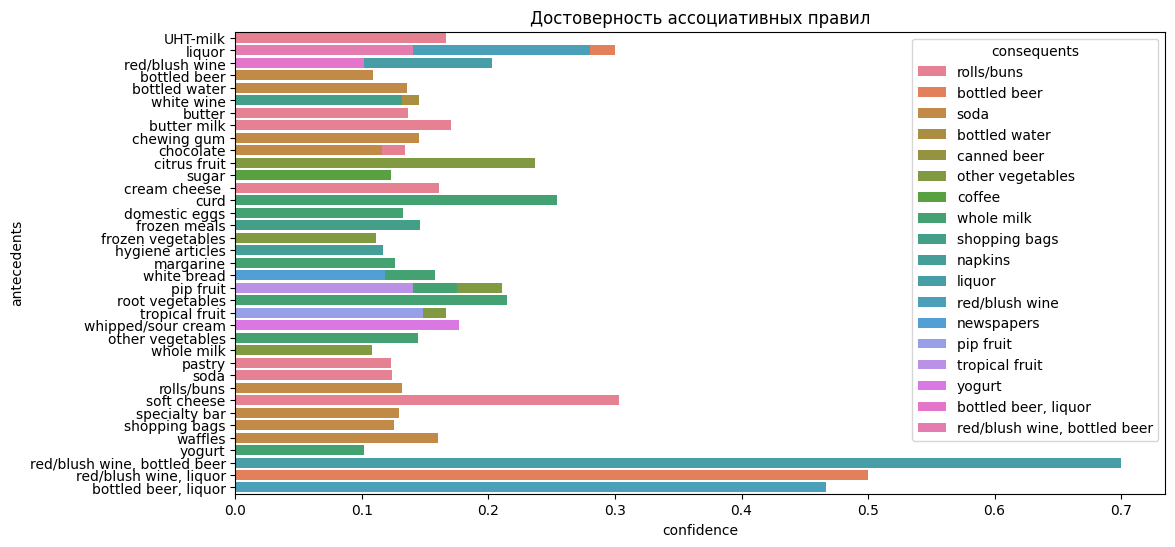

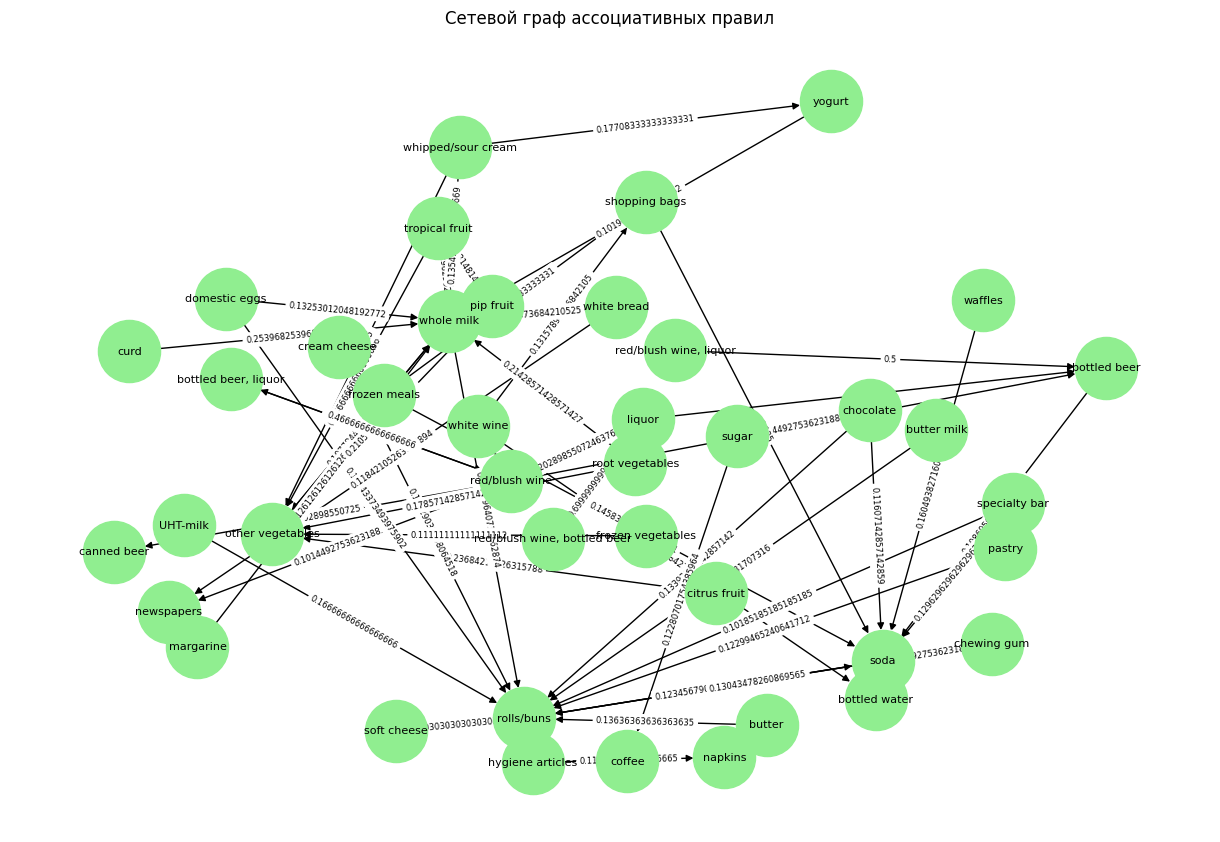

In [9]:
frequent_itemsets = apriori(data, min_support=0.001, use_colnames=True) # Уменьшение минимальной поддержки до 0.001
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

print("Частые наборы:")
print(frequent_itemsets.head())

print("\nАссоциативные правила:")
print(rules.head())

if not rules.empty:
    rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

    plt.figure(figsize=(12, 6))
    sns.barplot(x='confidence', y='antecedents', data=rules, hue='consequents', dodge=False)
    plt.title('Достоверность ассоциативных правил')
    plt.show()

    G = nx.DiGraph()
    for _, row in rules.iterrows():
        G.add_edge(row['antecedents'], row['consequents'], weight=row['confidence'])

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.5)
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightgreen', font_size=8, arrows=True)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
    plt.title('Сетевой граф ассоциативных правил')
    plt.show()
else:
    print("Нет правил для визуализации. Попробуйте уменьшить min_support или min_threshold.")

При уменьшении минимальной поддержки количество ассоциативных правил в наборе увеличивается. 

Частые наборы:
    support                 itemsets
0  0.002293  (Instant food products)
1  0.006880               (UHT-milk)
2  0.003276          (baking powder)
3  0.003604                   (beef)
4  0.002785                (berries)

Ассоциативные правила:
        antecedents         consequents  antecedent support  \
0          (liquor)      (bottled beer)            0.008190   
1    (citrus fruit)  (other vegetables)            0.006224   
2            (curd)        (whole milk)            0.010319   
3  (red/blush wine)            (liquor)            0.011302   
4          (liquor)    (red/blush wine)            0.008190   

   consequent support   support  confidence       lift  representativity  \
0            0.037674  0.002457    0.300000   7.963043               1.0   
1            0.040786  0.001474    0.236842   5.806912               1.0   
2            0.054709  0.002621    0.253968   4.642144               1.0   
3            0.008190  0.002293    0.202899  24.773913  

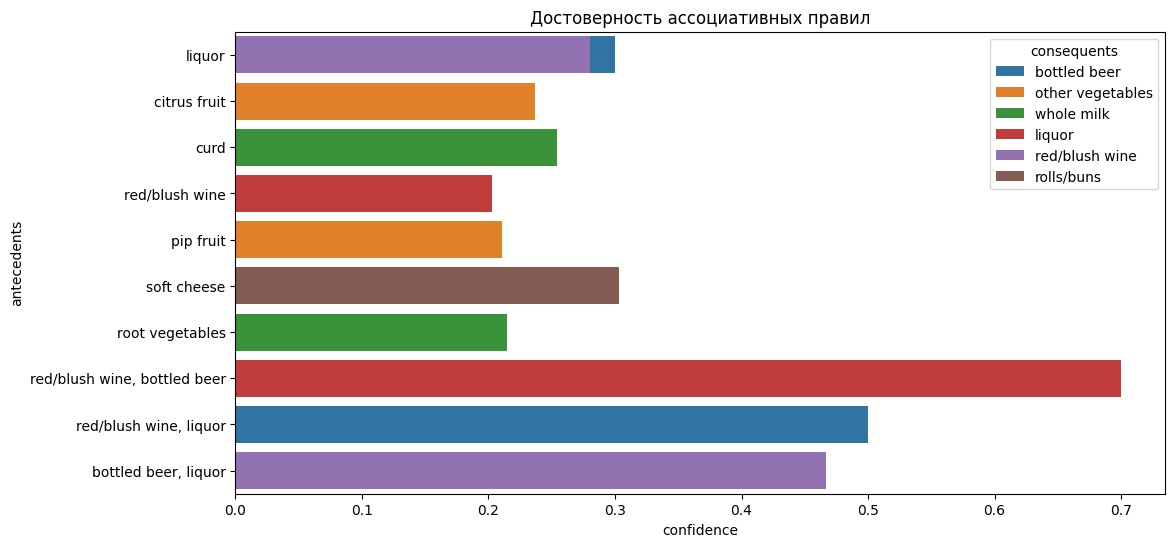

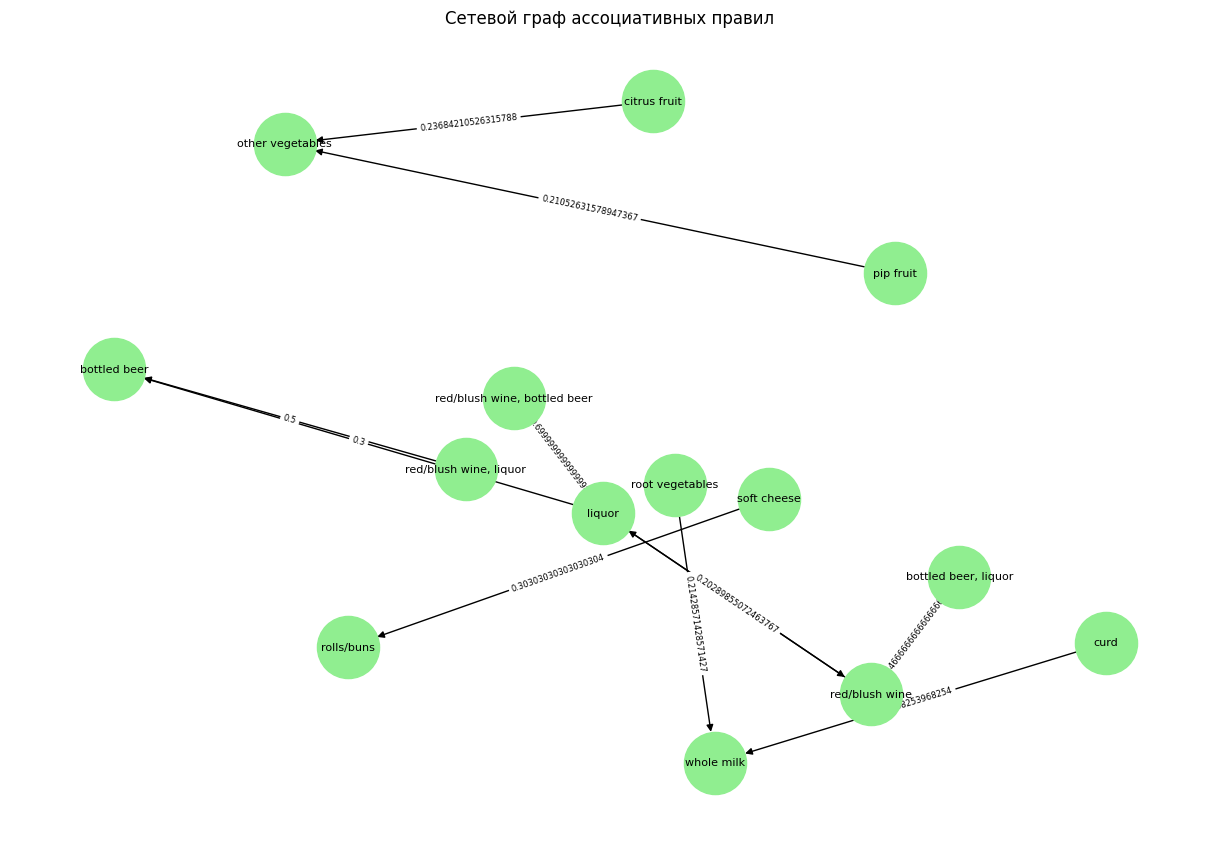

In [11]:
frequent_itemsets = apriori(data, min_support=0.001, use_colnames=True) # Уменьшение минимальной поддержки до 0.001
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)

print("Частые наборы:")
print(frequent_itemsets.head())

print("\nАссоциативные правила:")
print(rules.head())

if not rules.empty:
    rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

    plt.figure(figsize=(12, 6))
    sns.barplot(x='confidence', y='antecedents', data=rules, hue='consequents', dodge=False)
    plt.title('Достоверность ассоциативных правил')
    plt.show()

    G = nx.DiGraph()
    for _, row in rules.iterrows():
        G.add_edge(row['antecedents'], row['consequents'], weight=row['confidence'])

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.5)
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightgreen', font_size=8, arrows=True)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
    plt.title('Сетевой граф ассоциативных правил')
    plt.show()
else:
    print("Нет правил для визуализации. Попробуйте уменьшить min_support или min_threshold.")

При повышении минимальной достоверности количество выводимых правил уменьшается, так как этому условию соответствует малое количество правил 

**Реализация другого способа реализации ассоциативных правил. Тепловая карта достоверности правил**

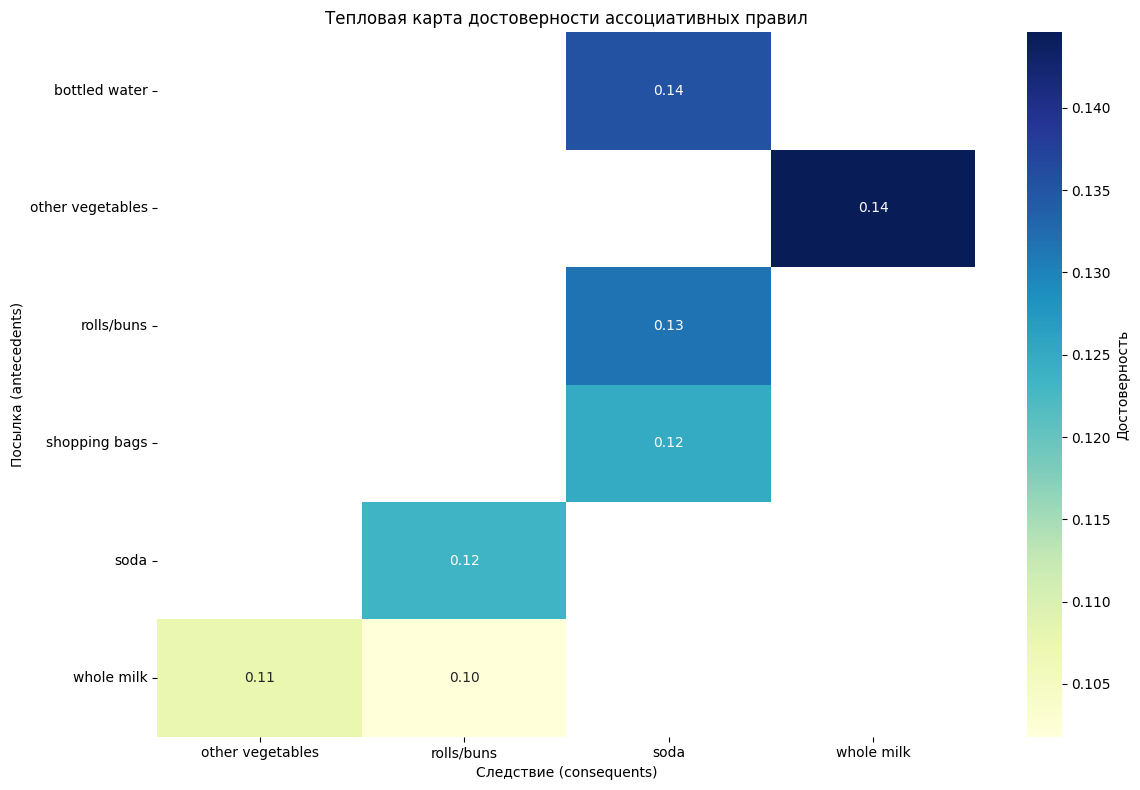

In [15]:
# Тепловая карта поддержки и достоверности
pivot_table = rules.pivot_table(
    index='antecedents',
    columns='consequents',
    values='confidence',
    aggfunc='max'
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Достоверность'}
)
plt.title('Тепловая карта достоверности ассоциативных правил')
plt.xlabel('Следствие (consequents)')
plt.ylabel('Посылка (antecedents)')
plt.tight_layout()
plt.show()